### 3. (a) Using Amazon Food Review data, classify reviews as positive or negative. 

In [1]:
!pip install kagglehub


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gayat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\gayat\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


100%|███████████████████████████████████████████████████████████████████████████████| 242M/242M [00:24<00:00, 10.6MB/s]

Extracting files...


Path to dataset files: C:\Users\gayat\.cache\kagglehub\datasets\snap\amazon-fine-food-reviews\versions\2
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                             

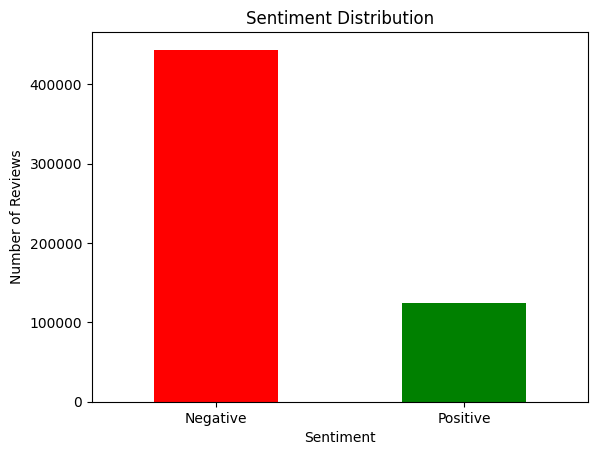

In [2]:
import nltk

# Download the stopwords dataset
nltk.download('stopwords')
# Download the 'punkt_tab' dataset
nltk.download('punkt_tab') # This line was added to download the punkt_tab dataset.


import kagglehub
import pandas as pd
import string
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Download the dataset
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

print("Path to dataset files:", path)

# Load the dataset (the CSV file is typically named 'Reviews.csv')
df = pd.read_csv(f"{path}/Reviews.csv")

# Check the first few rows to understand the structure
print(df.head())

# Data Preprocessing

# Preprocess the review text
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    stop_words = set(stopwords.words('english'))  # Set of stop words
    tokens = word_tokenize(text)  # Tokenization
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    return " ".join(tokens)

# Apply preprocessing to the review text
df['cleaned_reviews'] = df['Text'].apply(preprocess_text)

# Create sentiment labels based on ratings (1 = negative, 0 = positive)
df['sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

# Display cleaned data
print(df[['Text', 'cleaned_reviews', 'sentiment']].head())

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=5000)  # Limit to 5000 most important features
X = vectorizer.fit_transform(df['cleaned_reviews'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, df['sentiment'], test_size=0.2, random_state=42)

# Train a Logistic Regression model
model = LogisticRegression(max_iter=1000)  # Increase max_iter if convergence is an issue
model.fit(X_train, y_train)

# Predict sentiment on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Visualize the sentiment distribution
df['sentiment'].value_counts().plot(kind='bar', color=['red', 'green'], title="Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks([0, 1], ['Negative', 'Positive'], rotation=0)
plt.show()